# Beckmann rate Data with Ortho Substituents

This workbook contains the code and imports the data to explore the Beckmann hammett plot.

the data being plotted is from...

"Kinetics and mechanism of the Beckmann rearrangement of acetophenone oximes in sulphuric acid." Gregory, B. J., Moodie, R. B., & Schofield, K., *J. Chem. Soc. B*, **1970**, 338-346. https://doi.org/10.1039/j29700000338 



## Setup Tools and Read Substituent Data Table

Here the data table for Steric substitutent constants is read in and processed. Also the libraries are imported and any functions defined

In [1]:
# Generic Setup
# Imports and file locations
# 

####################################################
### Import Libraries and set up global variables ###
####################################################

# Install packages only if needed
# Coogle Colab does not include every Python package
#   
try:                  # if the package exists import it, otherwise install it
    import lmfit
except ImportError:
    !pip -q install lmfit
    import lmfit

try:
    import uncertainties
except ImportError:
    !pip -q install uncertainties
    import uncertainties

# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import linregress
from scipy.optimize import curve_fit

import uncertainties as un
from uncertainties import unumpy as unp

from matplotlib.ticker import FormatStrFormatter
from scipy.stats import t

from pathlib import Path

Path("plots").mkdir(exist_ok=True)
#Path("plots/stacking").mkdir(exist_ok=True)
#Path("plots/single").mkdir(exist_ok=True)
#Path("plots/fits").mkdir(exist_ok=True)

#Path("data").mkdir(exist_ok=True)

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

#if IN_COLAB and not Path("data/3c.csv").exists():
#    !wget -q -O data/3c.csv https://raw.githubusercontent.com/blinkletter/Chem4410Webbook/main/book/notebooks/M11_Plot_Recommendations/3c.csv

if IN_COLAB and not Path("tufte.mplstyle").exists():
    !wget -q https://raw.githubusercontent.com/blinkletter/Chem4410Webbook/main/book/styles/tufte.mplstyle
if IN_COLAB and not Path("data").exists():
    !wget -q https://raw.github.com/blinkletter/Chem4410Webbook/main/book/notebooks/M33_Beckmann/data.zip
    !unzip -q data.zip

github_location_LFER_tables = "https://raw.githubusercontent.com/blinkletter/LFER-QSAR/main/data/"

plt.rcdefaults()


style_file = "tufte.mplstyle"
#style_file = "S2_classic2.mplstyle"

# Set plot style for all plots

plt.style.use(style_file)  


In [2]:
#################################################################
### Load in table of sigma values and fill in any blanks.     ###
#################################################################

# a function to fill in sigma for empty spaces in s+ and s- ###
def fill_sigma(df):     
    for z in df.index:                                  # loop over all rows
        if np.isnan(df.loc[z,"s_plus"]):                # check if s_plus is nan
            df.loc[z,"s_plus"] = df.loc[z,"sigma"]      # if so, fill it with sigma value
        if np.isnan(df["s_minus"][z]):                  # check if s_minus is nan
            df.loc[z,"s_minus"] = df.loc[z,"sigma"]     # if so, fill it with sigma value
    return(df)

### Read data set. The fields are separated by commas; comments are enabled  

#LFER_file = "Taft_Es_Williams.csv"        # Choose a data set to load
#LFER_file = "LFER_HanschLeoTaft.csv"   
LFER_file = "LFER_Williams.csv"            # This had values for a few ortho substituents

data_set = pd.read_csv(github_location_LFER_tables + LFER_file,
                        delimiter = ",", 
                        skipinitialspace=True, 
                        index_col="Substituent", 
                        comment = "#") 
#display(data_set)

########################################################
### Fill across sigma values and select substituents ###
########################################################

data_set=fill_sigma(data_set)
#display(data_set)

###############################
### Remove unneeded columns ###
###############################

if LFER_file == "LFER_HanschLeoTaft.csv":
    data_set.drop(labels = ["TABLE V", "TABLE I"],      #Trim "LFER_HanschLeoTaft.csv" data
    axis = 1,
    inplace = True)
elif LFER_file == "LFER_Williams.csv":
    data_set.drop(labels = ["Page"],                   #Trim "LFER_Williams.csv"" data
    axis = 1,
    inplace = True)
else:
    print("ERROR: No filename")

### Sort by Steric Size and display -- if needed

#data_set.sort_values(by=['sigma'], inplace=True)
#data_set.sort_values(by=["E'(s)"], inplace=True)

display(data_set)    # This displays the full table of substituent parameters

,sigma,s_plus,s_minus
Substituent,,,
m-Br,0.39,0.39,0.39
p-Br,0.23,0.15,0.25
m-C6H5,0.06,0.06,0.06
p-C6H5,-0.01,0.02,-0.18
m-CCCH3,0.10,0.10,0.10
...,...,...,...
p-C(CH3)3,-0.20,-0.26,-0.13
m-C(CH3)3,-0.10,-0.10,-0.10
"3,5-CH3",-0.12,-0.12,-0.12


## Read Experimental Data for Acid Hydrolysis
Here the data from the publication is read in. It had been saved in a csv file. the data is from...

"Kinetics and mechanism of the Beckmann rearrangement of acetophenone oximes in sulphuric acid." Gregory, B. J., Moodie, R. B., & Schofield, K., *J. Chem. Soc. B*, **1970**, 338-346. https://doi.org/10.1039/j29700000338 


In [3]:
############################################
### Read in data from literature example ###
############################################

datafile = "data/Table1and2All.csv"

df = pd.read_csv(datafile, 
                 delimiter = ",", 
                 skipinitialspace=True, 
                 index_col="Substituent", 
                 comment = "#")
df["kobs"] = 10**(-4) * df["kobs"]
df["log_k"] = np.log10(df["kobs"])

#display(df.head())

# filter dataframe for rows where %H2SO4 is 98.2 and TempC is 80
df = df[(df['%H2SO4'] == 98.2) & (df['TempC'] == 60)]
display(df)
Beckmann_data = df.copy()

,Name,%H2SO4,TempC,kobs,log_k
Substituent,,,,,
H,Hydrogen,98.2,60.0,0.000180,-3.744727
p-Br,p-Bromo,98.2,60.0,0.000108,-3.966576
p-Cl,p-Chloro,98.2,60.0,0.000112,-3.950782
p-F,p-Fluoro,98.2,60.0,0.000126,-3.899629
p-I,p-Iodo,98.2,60.0,0.000124,-3.906578
p-CH3,p-Methyl,98.2,60.0,0.000320,-3.494850
p-NO2,p-Nitro,98.2,60.0,0.000006,-5.229148
o-F,o-Fluoro,98.2,60.0,0.000062,-4.207608
o-Cl,o-Chloro,98.2,60.0,0.001220,-2.913640


## Combine Data Sets

Both data sets are indexed by "Substituent". The code below will combine the two data sets according to "Substituent" and take the intersection of the sets.

## Calculations

We need the log of the rate. Also we will convert the rate to SI units. The current units are in $10^{-4} s^{-1}$. We will convert to $s^{-1}$ by multiplying by $10^4$.


In [4]:
##################################################
### Combine data sets using the index column.  ###
### Data lines that share an index column will ###
### be combined, all other ignored.            ###
##################################################

combined_data = pd.concat([Beckmann_data, data_set], axis=1, join="inner")
#display(combined_data_acid)

#########################################################################
### Perform calculations on columns and add new columns with results  ###
#########################################################################

#combined_data.drop(labels = ["o-NO2","o-Cl","o-CH3"], axis = 0, inplace = True)  # remove the "o-NO2" data point.
#combined_data.drop(labels = ["p-OH"], axis = 0, inplace = True)  # remove the "o-NO2" data point.



# set combined_data["Substituent"]["s_plus"] to a value of 5
#combined_data.loc["m-N(CH3)3+","s_plus"] = 0.36
display(combined_data)

,Name,%H2SO4,TempC,kobs,log_k,sigma,s_plus,s_minus
Substituent,,,,,,,,
H,Hydrogen,98.2,60.0,0.000180,-3.744727,0.00,0.00,0.00
p-Br,p-Bromo,98.2,60.0,0.000108,-3.966576,0.23,0.15,0.25
p-Cl,p-Chloro,98.2,60.0,0.000112,-3.950782,0.23,0.11,0.19
p-F,p-Fluoro,98.2,60.0,0.000126,-3.899629,0.06,-0.07,-0.03
p-I,p-Iodo,98.2,60.0,0.000124,-3.906578,0.18,0.14,0.27
p-CH3,p-Methyl,98.2,60.0,0.000320,-3.494850,-0.14,-0.31,-0.17
p-NO2,p-Nitro,98.2,60.0,0.000006,-5.229148,0.78,0.78,1.24
o-F,o-Fluoro,98.2,60.0,0.000062,-4.207608,0.93,0.93,0.93
o-Cl,o-Chloro,98.2,60.0,0.001220,-2.913640,1.26,1.26,1.26


In [5]:
################################################################################
### Read data set. The fields are separated by commas; comments are enabled  ###
################################################################################

#LFER_file = "TaFT_Es_Williams.csv"   
LFER_file = "Ortho_Es_Williams.csv"   
#LFER_file = "LFER_HanschLeoTaft.csv"   
#LFER_file = "LFER_Williams.csv"   ### This had values for a few ortho substituents

data_set = pd.read_csv(github_location_LFER_tables + LFER_file,
                 delimiter = ",", 
                 skipinitialspace=True, 
                 index_col="Substituent", 
                 comment = "#") 
#drop column "sigma"
data_set.drop(labels = ["sigma"], axis = 1, inplace = True)

display(data_set)

##################################################
### Combine data sets using the index column.  ###
### Data lines that share an index column will ###
### be combined, all other ignored.            ###
##################################################

combined_data_ortho = pd.concat([combined_data, data_set], axis=1, join="inner")
display(combined_data_ortho)



,E(s),sigma*,u
Substituent,,,
o-OCH3,0.99,-0.22,NaN
o-OEt,0.90,NaN,NaN
o-CH3,0.00,0.00,0.52
o-F,0.49,0.41,0.27
o-Cl,0.18,0.37,0.55
o-Br,0.00,0.38,0.65
o-I,-0.20,0.38,0.78
o-NO2,-0.75,0.97,0.35
o-C6H5,-0.90,NaN,NaN


,Name,%H2SO4,TempC,kobs,log_k,sigma,s_plus,s_minus,E(s),sigma*,u
Substituent,,,,,,,,,,,
o-F,o-Fluoro,98.2,60.0,0.000062,-4.207608,0.93,0.93,0.93,0.49,0.41,0.27
o-Cl,o-Chloro,98.2,60.0,0.001220,-2.913640,1.26,1.26,1.26,0.18,0.37,0.55
o-Br,o-Bromo,98.2,60.0,0.001730,-2.761954,1.35,1.35,1.35,0.00,0.38,0.65
o-I,o-Iodo,98.2,60.0,0.004100,-2.387216,1.34,1.34,1.34,-0.20,0.38,0.78
o-CH3,o-Methyl,98.2,60.0,0.016200,-1.790485,0.29,0.29,0.29,0.00,0.00,0.52
o-NO2,o-Nitro,98.2,60.0,0.000023,-4.638272,2.03,2.03,2.03,-0.75,0.97,0.35


## Plot and Curve Fits

The code below will extract the x,y data for our plots and perform the linear fit to the hammett equation. I have decided to put boths ets of data on the same plot for comparison sake. You will see exactly what i have done by examining the code.

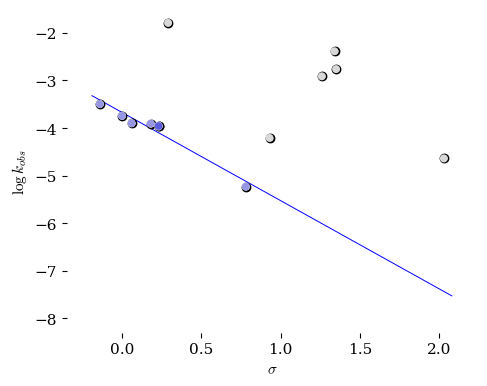

Beckmann (open circles)
slope  = -1.85
intercept = -3.673
RSQ = 0.953
LinregressResult(slope=np.float64(-1.852380788976813), intercept=np.float64(-3.6728716056098265), rvalue=np.float64(-0.9761911136353517), pvalue=np.float64(0.00016585921387378148), stderr=np.float64(0.18407483859570464), intercept_stderr=np.float64(0.06104278811721909))


In [6]:

from scipy.stats import linregress
import matplotlib

#####################################################
### Get series of data to plot from the dataframe ###
#####################################################

x = combined_data["sigma"]
y = combined_data["log_k"]

##################################################
### Setup a figure with two plots side-by-side ###
### and choose a stylesheet                    ###
##################################################

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  
ax.margins(x=.07, y=.07, tight=True)      # add 7% empty space around outside of plot area   

#########################################
### Plot the data and the line fit.   ###
#########################################

ax.scatter(x,y, s = 32, color="white",  edgecolors = "black", zorder=2, linewidths=1.4)
ax.scatter(x,y, s = 32, color="white",  edgecolors = "none", alpha = 1, zorder=2)
ax.scatter(x,y, s = 32, color="gray",  edgecolors = "none", alpha = 0.3, zorder=4)

if True:   # Flag to run or not. True = run this section, False = skip it

    # Using str.startswith() on the index
    #filtered_df = combined_data[df.index.str.startswith('m')]
    
    index_list = ['p-Cl', 'p-Br', 'p-F', 'p-I', 'p-CH3', 'H', 'p-NO2']
    # Filter rows in the dataframe where the index is in index_list
    filtered_df = combined_data.loc[combined_data.index.isin(index_list)]


    xf = filtered_df["sigma"] 
    yf =  filtered_df["log_k"]
    ax.scatter(xf,yf, s = 32, color="white",  edgecolors = "none", alpha = 1, zorder=2)
    ax.scatter(xf,yf, s = 32, color="blue",  edgecolors = "none", alpha = 0.3, zorder=4)


    linfit = linregress(xf,yf)
    #x_fit = np.linspace(-0.8, 0.8, 100)
    x_fit = np.linspace(min(x)-0.05, max(x)+0.05, 100)
    fit = linfit.slope * x_fit + linfit.intercept
    ax.plot(x_fit, fit, color='blue', zorder=1, linewidth=0.7)


############################
### Set labels and scale ###
############################

xlabel_string = r"$\sigma$"
#xlabel_string = r"$\sigma^+$"
#xlabel_string = r"$\sigma + r(\sigma^+-\sigma)$, $r = 0.43$"

ax.set(
#    title="Hammett Plot",       
          ylabel=r"$\log{k_{obs}}$", 
          xlabel=xlabel_string,                
#          xlim=[-1,1],                  
          ylim=[-8.3,-1.5],
#          xticks = (-1, -0.5, 0, 0.5, 1.0),
         )

if False:    # Flag to run or not. True = run this section, False = skip it
    for name,x_place,y_place in zip(list(combined_data.index),x,y):
        plt.annotate(name, # this is the text
                    (x_place,y_place), # these are the coordinates to position the label
                    textcoords="offset points", # how to position the text
                    xytext=(30,0), # distance from text to points (x,y)
                    ha='left') # horizontal alignment can be left, right or center


fig.savefig("plots/Fig_10_ortho.pdf")   # use this to save the figure in PDF format
plt.show()                 # output the combined plot plots

#make_axes_area_auto_adjustable(ax)
#####################################
### Print the line fit parameters ###
#####################################
print("Beckmann (open circles)")
print(f"slope  = {linfit.slope:0.2f}")
print(f"intercept = {linfit.intercept:0.3f}")
print(f"RSQ = {(linfit.rvalue**2):0.3f}")
print(linfit)




# Two Parameter Plot

We could create a two-parameter plot that combines the electronic effects and steric effects of the substituents on the benzene ring of acetophenone oxime.

I will use the reported $\sigma$ values from Williams' textbook and Charton's $\upsilon$ steric parameters. If the steric effect is proportional with group size then we should see the points move to be linear. The equation will be...

$$\log{k_{obs}} = \rho \sigma + \Chi \upsilon$$

/var/folders/_0/pb9y62rd59n_3vs7rbl1bndm0000gn/T/ipykernel_73113/616922566.py:3: Pandas4Warning: The 'mode.copy_on_write' option is deprecated. Copy-on-Write can no longer be disabled (it is always enabled with pandas >= 3.0), and setting the option has no impact. This option will be removed in pandas 4.0.
  pd.options.mode.copy_on_write = True


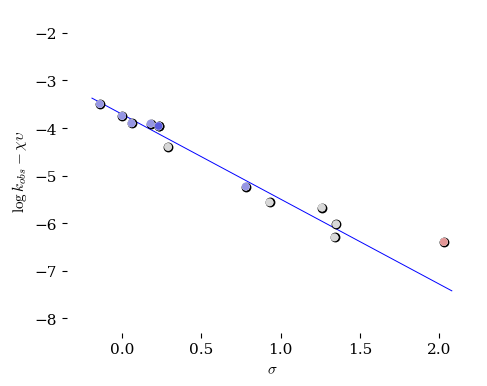

Beckmann (open circles)
slope  = -1.78
intercept = -3.711
RSQ = 0.974
LinregressResult(slope=np.float64(-1.783272390999632), intercept=np.float64(-3.710841811377162), rvalue=np.float64(-0.9868323440312406), pvalue=np.float64(3.0495648739019474e-09), stderr=np.float64(0.09242919204646598), intercept_stderr=np.float64(0.07021222623416395))


In [7]:

from scipy.stats import linregress
import matplotlib
pd.options.mode.copy_on_write = True

combined_data2 = combined_data.copy()
combined_data2["u"] = 0.            # the decimal is required to make the column a float type
for sub in combined_data_ortho.index:
    combined_data2.loc[sub, "u"] = combined_data_ortho.loc[sub, "u"]

#combined_data2.loc["o-NO2", "u"] = 0.55    # set specific value for o-NO2

# delete rom for "o-NO2" from combined_data2
combined_data3 = combined_data2.drop(labels = ["o-NO2"], axis = 0, inplace = False)  # remove the "o-NO2" data point.

#####################################################
### Get series of data to plot from the dataframe ###
#####################################################

chi = 5.013

x = combined_data2["sigma"]
y = combined_data2["log_k"]
u = combined_data2["u"]
yc = y - chi * u

##################################################
### Setup a figure with two plots side-by-side ###
### and choose a stylesheet                    ###
##################################################

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  
ax.margins(x=.07, y=.07, tight=True)      # add 7% empty space around outside of plot area   

#########################################
### Plot the data and the line fit.   ###
#########################################

ax.scatter(x,yc, s = 32, color="white",  edgecolors = "black", zorder=2, linewidths=1.4)
ax.scatter(x,yc, s = 32, color="white",  edgecolors = "none", alpha = 1, zorder=2)
ax.scatter(x,yc, s = 32, color="gray",  edgecolors = "none", alpha = 0.3, zorder=4)

if True:   # Flag to run or not. True = run this section, False = skip it

    # Using str.startswith() on the index
    #filtered_df = combined_data[df.index.str.startswith('m')]
    
    index_list = ['p-Cl', 'p-Br', 'p-F', 'p-I', 'p-CH3', 'H', 'p-NO2']
    # Filter rows in the dataframe where the index is in index_list
    filtered_df = combined_data.loc[combined_data.index.isin(index_list)]


    xf = filtered_df["sigma"] 
    yf =  filtered_df["log_k"]
    ax.scatter(xf,yf, s = 32, color="white",  edgecolors = "none", alpha = 1, zorder=2)
    ax.scatter(xf,yf, s = 32, color="blue",  edgecolors = "none", alpha = 0.3, zorder=4)

    x3 = combined_data3["sigma"]
    y3 = combined_data3["log_k"]
    u3 = combined_data3["u"]
    
    y3 = y3 - chi * u3

    linfit = linregress(x3,y3)
    #x_fit = np.linspace(-0.8, 0.8, 100)
    x_fit = np.linspace(min(x)-0.05, max(x)+0.05, 100)
    fit = linfit.slope * x_fit + linfit.intercept
    ax.plot(x_fit, fit, color='blue', zorder=1, linewidth=0.7)

    x_NO2 = combined_data2.loc["o-NO2", "sigma"]
    y_NO2 = combined_data2.loc["o-NO2", "log_k"] - chi * combined_data2.loc["o-NO2", "u"]
    ax.scatter(x_NO2,y_NO2, s = 32, color="white",  edgecolors = "none", alpha = 1, zorder=2)
    ax.scatter(x_NO2,y_NO2, s = 32, color="red",  edgecolors = "none", alpha = 0.3, zorder=4)

############################
### Set labels and scale ###
############################

xlabel_string = r"$\sigma$"
#xlabel_string = r"$\sigma^+$"
#xlabel_string = r"$\sigma + r(\sigma^+-\sigma)$, $r = 0.43$"

ax.set(
#    title="Hammett Plot",       
          ylabel=r"$\log{k_{obs}}-\chi\upsilon$", 
          xlabel=xlabel_string,                
#          xlim=[-1,1],                  
          ylim=[-8.3,-1.5],
#          xticks = (-1, -0.5, 0, 0.5, 1.0),
         )

if False:    # Flag to run or not. True = run this section, False = skip it
    for name,x_place,y_place in zip(list(combined_data.index),x,y):
        plt.annotate(name, # this is the text
                    (x_place,y_place), # these are the coordinates to position the label
                    textcoords="offset points", # how to position the text
                    xytext=(30,0), # distance from text to points (x,y)
                    ha='left') # horizontal alignment can be left, right or center


fig.savefig("plots/Fig_10_ortho_size.pdf")   # use this to save the figure in PDF format
plt.show()                 # output the combined plot plots

#make_axes_area_auto_adjustable(ax)
#####################################
### Print the line fit parameters ###
#####################################
print("Beckmann (open circles)")
print(f"slope  = {linfit.slope:0.2f}")
print(f"intercept = {linfit.intercept:0.3f}")
print(f"RSQ = {(linfit.rvalue**2):0.3f}")
print(linfit)



## Optimize $\chi$

The code below was stolen from the optimization of *r* in the Yukawa-Tsuno plot and repurposed to optimize the value of $\chi$ in my two-parameter plot.

Substituent
H       -3.744727
p-Br    -3.966576
p-Cl    -3.950782
p-F     -3.899629
p-I     -3.906578
p-CH3   -3.494850
p-NO2   -5.229148
o-F     -4.207608
o-Cl    -2.913640
o-Br    -2.761954
o-I     -2.387216
o-CH3   -1.790485
Name: log_k, dtype: float64


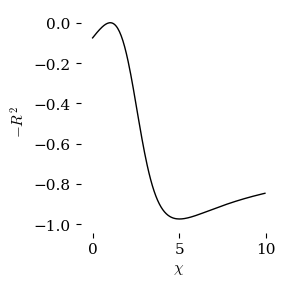

The optimal value for r is 5.015 for rsq = -0.97384


In [8]:
from scipy.optimize import minimize_scalar

dfx = combined_data3.copy()

#####################################################
### Get series of data to plot from the dataframe ###
#####################################################

chi = 0
x = dfx["sigma"]
y = dfx["log_k"]
u = dfx["u"]
print(y)



def RSQ_function(chi,x,y,u):    # returns the RSQ for linefits using the given Yukawa-Tsuno r factor
    y1 = y - chi * u
    linfit = linregress(x,y1)
    return -(linfit.rvalue**2)


##########################################################
### Plot the value of -RSQ as the value of r is varied ###
##################################################

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3,3))  
ax.margins(x=.07, y=.07, tight=True)      # add 7% empty space around outside of plot area   
ax.set(ylabel=r"$-R^2$", 
       xlabel=r"$\chi$")

rsq_range=[]
r_range = np.arange(0., 10. ,0.05)
for r in r_range:
    rsq = RSQ_function(r,x,y,u)
    rsq_range.append(rsq)
    
ax.plot(r_range,rsq_range)
#ax.hlines(-0.98, xmin=0, xmax=1, colors='gray', linestyles='dashed')
#ax.vlines(0.43, ymin=-0.99, ymax=-0.95, colors='gray', linestyles='dashed')
#ax.vlines(0.67, ymin=-0.99, ymax=-0.95, colors='gray', linestyles='dashed')
fig.savefig("plots/Fig_10_optimization.pdf")   # use this to save the figure in PDF format
plt.show()

##################################################
### Determine optimal r value to minimize -RSQ ###
##################################################


fun=lambda chi: RSQ_function(chi, x,y,u)
r_opt = minimize_scalar(fun, bounds=(4, 6), method='bounded')
print(f"The optimal value for r is {r_opt['x']:0.3f} for rsq = {r_opt['fun']:0.5f}")


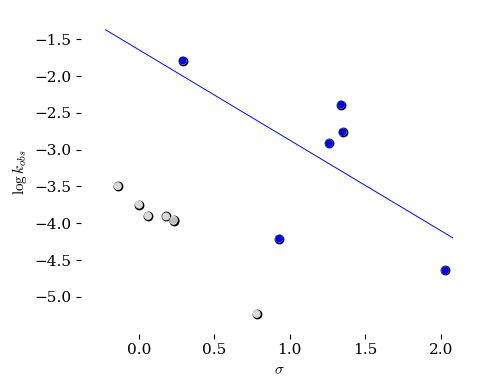

Beckmann (open circles)
slope  = -1.23
intercept = -1.644
RSQ = 0.413
LinregressResult(slope=np.float64(-1.227495763177521), intercept=np.float64(-1.6435343624233487), rvalue=np.float64(-0.6428564378511106), pvalue=np.float64(0.16855018315994263), stderr=np.float64(0.7313027871371555), intercept_stderr=np.float64(0.9570292213220825))


In [9]:

from scipy.stats import linregress
import matplotlib

#####################################################
### Get series of data to plot from the dataframe ###
#####################################################

r = 0.0
#x = combined_data["sigma"]
#x = combined_data["s_plus"]
x = combined_data["sigma"] + r*(combined_data["s_plus"]-combined_data["sigma"])  # Yukawa Tsuno

y =  combined_data["log_k"]

##################################################
### Setup a figure with two plots side-by-side ###
### and choose a stylesheet                    ###
##################################################

plt.style.use(style_file)        

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  
ax.margins(x=.07, y=.07, tight=True)      # add 7% empty space around outside of plot area   

#########################################
### Plot the data and the line fit.   ###
#########################################

#ax.plot(x, y, color='black', zorder=1, linewidth=0.7)

#ax.scatter(x,y, s=128, color="white",  edgecolors = "none", zorder=2)
ax.scatter(x,y, s = 32, color="white",  edgecolors = "black", zorder=2, linewidths=1.4)
ax.scatter(x,y, s = 32, color="white",  edgecolors = "none", alpha = 1, zorder=2)
ax.scatter(x,y, s = 32, color="gray",  edgecolors = "none", alpha = 0.3, zorder=4)

#ax.scatter(x,y, s = 32, marker="|", color="black",  alpha = 1, zorder=2, linewidth=0.7)
#ax.scatter(x,y, s = 8, marker="o", color="black",  edgecolors = "none", alpha = 1, zorder=2)


if True:   # Flag to run or not. True = run this section, False = skip it

    # Using str.startswith() on the index
    #filtered_df = combined_data[df.index.str.startswith('m')]
    
    index_list = ['o-Cl', 'o-Br', 'o-F', 'o-I', 'o-CH3', 'o-NO2']
    # Filter rows in the dataframe where the index is in index_list
    filtered_df = combined_data.loc[combined_data.index.isin(index_list)]



    xf = filtered_df["sigma"] + r*(filtered_df["s_plus"]-filtered_df["sigma"])  # Yukawa Tsuno
    yf =  filtered_df["log_k"]
    ax.scatter(xf,yf, s = 32, color="blue",  edgecolors = "none", alpha = 1, zorder=4)

    linfit = linregress(xf,yf)
    #x_fit = np.linspace(-0.8, 0.8, 100)
    x_fit = np.linspace(min(x)-0.08, max(x)+0.05, 100)
    fit = linfit.slope * x_fit + linfit.intercept
    ax.plot(x_fit, fit, color='blue', zorder=1, linewidth=0.7)

if False:   #Set to True to see bounds of sigma and sigma plus values
    x1 = combined_data["sigma"]
    x2 = combined_data["s_plus"]

    n = 3
    ax.text(x1.iloc[n], y.iloc[n]+0.07, r"$\sigma$", color="red")  # Label for sigma values
    ax.text(x2.iloc[n]-0.03, y.iloc[n]+0.07, r"$\sigma^+$", color = "red")
#    ax.text(x1.iloc[n]+0.05, y.iloc[n]+0.0, r"$p$-OMe", color="black")  # Label for sigma values

    data = zip(x1, x2, y)

    for x1, x2, y1 in data:
        if x1 != x2:

            #ax.scatter(x1,y, s=64, marker="|", color="white", zorder=1)
            #ax.scatter(x2,y, s=64, marker="|", color="white", zorder=1)
            #ax.hlines(y=y, xmin=x2, xmax=x1, colors='white', linestyles='solid', zorder=1, linewidth=2)
        
            ax.scatter(x1,y1, s=64, marker="|", color="red", zorder=1, linewidths=0.7)
            ax.scatter(x2,y1, s=64, marker="|", color="red", zorder=1, linewidths=0.7)
            ax.hlines(y=y1, xmin=x2, xmax=x1, colors='red', linestyles='solid', zorder=1, linewidth=0.7)

############################
### Set labels and scale ###
############################

xlabel_string = r"$\sigma$"
#xlabel_string = r"$\sigma^+$"
#xlabel_string = r"$\sigma + r(\sigma^+-\sigma)$, $r = 0.43$"

ax.set(
#    title="Hammett Plot",       
          ylabel=r"$\log{k_{obs}}$", 
          xlabel=xlabel_string,                
#          xlim=[-1,1],                  
#          ylim=[-4.2,-2.25],
#          xticks = (-1, -0.5, 0, 0.5, 1.0),
         )

if False:    # Flag to run or not. True = run this section, False = skip it
    for name,x_place,y_place in zip(list(combined_data.index),x,y):
        plt.annotate(name, # this is the text
                    (x_place,y_place), # these are the coordinates to position the label
                    textcoords="offset points", # how to position the text
                    xytext=(30,0), # distance from text to points (x,y)
                    ha='left') # horizontal alignment can be left, right or center


#fig.savefig("plots/figureXselectedortho.pdf")   # use this to save the figure in PDF format
plt.show()                 # output the combined plot plots

#make_axes_area_auto_adjustable(ax)
#####################################
### Print the line fit parameters ###
#####################################
print("Beckmann (open circles)")
print(f"slope  = {linfit.slope:0.2f}")
print(f"intercept = {linfit.intercept:0.3f}")
print(f"RSQ = {(linfit.rvalue**2):0.3f}")
print(linfit)


